# Predicting Sector Trends with Gated Recurrent Unit Model

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Plotting & Display Settings ---
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

## Basic Data Exploration

In [ ]:
# --- Load Dataset ---
file_path = "indicators_test.csv"  # Update this if needed
df = pd.read_csv(file_path)

print("✅ Data loaded successfully")
print(f"Number of rows: {len(df):,}")
print(f"Number of columns: {len(df.columns)}")

✅ Data loaded successfully
Number of rows: 377,679
Number of columns: 22


In [9]:
# --- Inspect Columns ---
print("Columns:")
print(df.columns.tolist())

# --- Peek at Data ---
df.head()

Columns:
['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'Sector', 'Return', 'LogReturn', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Mid', 'BB_Upper', 'BB_Lower', 'ATR_14']


,Date,Ticker,Open,High,Low,Close,Volume,Sector,Return,LogReturn,SMA_20,SMA_50,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,MACD_Hist,BB_Mid,BB_Upper,BB_Lower,ATR_14
0,2018-10-01 04:00:00,AAPL,227.95,229.42,226.35,227.26,24974186.0,Technology,0.006733,0.006711,222.3330,213.9688,222.739766,220.158598,62.496156,2.581167,2.624908,-0.043741,222.3330,229.224618,215.441382,4.233214
1,2018-10-02 04:00:00,AAPL,227.25,230.00,226.63,229.28,26475439.0,Technology,0.008888,0.008849,222.3790,214.7222,223.745956,220.834258,64.910626,2.911698,2.682266,0.229432,222.3790,229.449951,215.308049,4.171555
2,2018-10-03 04:00:00,AAPL,230.05,233.47,229.78,232.07,30351891.0,Technology,0.012169,0.012095,222.6390,215.5036,225.026578,221.666535,67.977131,3.360043,2.817821,0.542221,222.6390,230.716084,214.561916,4.172873
3,2018-10-04 04:00:00,AAPL,230.78,232.35,226.73,227.99,34138275.0,Technology,-0.017581,-0.017737,222.8835,216.1670,225.482489,222.134940,59.753360,3.347549,2.923767,0.423782,222.8835,231.307921,214.459079,4.276239
4,2018-10-05 04:00:00,AAPL,227.96,228.41,220.58,224.29,35259625.0,Technology,-0.016229,-0.016362,223.0330,216.7686,225.299029,222.294574,53.439475,3.004455,2.939905,0.064551,223.0330,231.445214,214.620786,4.530079


In [10]:
# --- Column dtypes ---
print("\nColumn dtypes:")
print(df.dtypes)


Column dtypes:
Date            object
Ticker          object
Open           float64
High           float64
Low            float64
Close          float64
Volume         float64
Sector          object
Return         float64
LogReturn      float64
SMA_20         float64
SMA_50         float64
EMA_12         float64
EMA_26         float64
RSI_14         float64
MACD           float64
MACD_Signal    float64
MACD_Hist      float64
BB_Mid         float64
BB_Upper       float64
BB_Lower       float64
ATR_14         float64
dtype: object


In [11]:
# --- Basic Structure ---
if 'Ticker' in df.columns:
    print(f"Unique tickers: {df['Ticker'].nunique()}")

if 'Industry' in df.columns:
    print(f"Unique industries: {df['Industry'].nunique()}")
    print("Industries:", df['Industry'].unique())

if 'Date' in df.columns:
    # Convert Date to datetime if not already
    if not np.issubdtype(df['Date'].dtype, np.datetime64):
        df['Date'] = pd.to_datetime(df['Date'])
    print(f"Date range: {df['Date'].min()} → {df['Date'].max()}")

Unique tickers: 220
Date range: 2018-10-01 04:00:00 → 2025-10-01 04:00:00


## Return and LogReturn Verification

This cell validates the accuracy and scaling of the **Return** and **LogReturn** columns in the dataset.  
It recalculates daily percentage and log returns from the `Close` price for each ticker, then compares these against the provided values to detect inconsistencies or scaling errors (e.g., whether returns were expressed as raw values, percentages, or decimals).

After determining the best matching scale, the script creates verified columns — `Return_verified` and `LogReturn_verified` — ensuring precise alignment with recomputed values.  
This verification step guarantees data consistency and numerical correctness before using returns in later modeling or performance evaluation.

In [12]:
# === Verify Return / LogReturn accuracy (per Ticker, using Close) ===
import numpy as np
import pandas as pd

# Ensure sorted for pct_change
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

# Recompute daily returns from Close per ticker
grp = df.groupby('Ticker', group_keys=False)
ret_from_close = grp['Close'].pct_change()                   # NaN for first day per ticker
logret_from_close = np.log1p(ret_from_close)                 # consistent with simple return

# Helper to evaluate scaling hypotheses for provided Return
def evaluate_return_match(provided, recomputed, name="Return"):
    # Three hypotheses: raw, /100, *100
    candidates = {
        'raw': provided,
        'div100': provided / 100.0,
        'mul100': provided * 100.0
    }
    stats = {}
    for k, series in candidates.items():
        # Compare only where both are finite
        mask = np.isfinite(series) & np.isfinite(recomputed)
        abs_diff = (series[mask] - recomputed[mask]).abs()
        stats[k] = {
            'mean_abs_diff': abs_diff.mean() if len(abs_diff) else np.nan,
            'median_abs_diff': abs_diff.median() if len(abs_diff) else np.nan,
            'max_abs_diff': abs_diff.max() if len(abs_diff) else np.nan,
            'n_compared': int(mask.sum())
        }
    # Pick best by mean_abs_diff
    best_key = min(stats, key=lambda k: (np.inf if pd.isna(stats[k]['mean_abs_diff']) else stats[k]['mean_abs_diff']))
    return best_key, stats

# Evaluate Return
best_return_scale, return_stats = evaluate_return_match(df['Return'], ret_from_close, "Return")

# Build a "verified" Return aligned to recomputed scale
if best_return_scale == 'raw':
    return_verified = df['Return']
elif best_return_scale == 'div100':
    return_verified = df['Return'] / 100.0
else:  # 'mul100'
    return_verified = df['Return'] * 100.0

# Final comparison using a reasonable tolerance
RET_TOL = 1e-8
ret_mask = np.isfinite(return_verified) & np.isfinite(ret_from_close)
ret_mismatch = (return_verified[ret_mask] - ret_from_close[ret_mask]).abs() > RET_TOL

print("=== Return column verification ===")
print(f"Best scale match for provided 'Return': {best_return_scale}")
print(f"Compared rows: {return_stats[best_return_scale]['n_compared']:,}")
print(f"Mean abs diff: {return_stats[best_return_scale]['mean_abs_diff']:.3e}")
print(f"Median abs diff: {return_stats[best_return_scale]['median_abs_diff']:.3e}")
print(f"Max abs diff: {return_stats[best_return_scale]['max_abs_diff']:.3e}")
print(f"Mismatches (> {RET_TOL:g}): {int(ret_mismatch.sum()):,} ({100*ret_mismatch.mean():.3f}%)")

# Evaluate LogReturn (always compare to np.log1p(simple_return))
LOG_TOL = 1e-10
log_mask = np.isfinite(df['LogReturn']) & np.isfinite(logret_from_close)
log_abs_diff = (df.loc[log_mask, 'LogReturn'] - logret_from_close[log_mask]).abs()
log_mismatch = log_abs_diff > LOG_TOL

print("\n=== LogReturn column verification ===")
print(f"Compared rows: {int(log_mask.sum()):,}")
print(f"Mean abs diff: {log_abs_diff.mean():.3e}")
print(f"Median abs diff: {log_abs_diff.median():.3e}")
print(f"Max abs diff: {log_abs_diff.max():.3e}")
print(f"Mismatches (> {LOG_TOL:g}): {int(log_mismatch.sum()):,} ({100*log_mismatch.mean():.3f}%)")

# Keep non-overwriting "verified" columns for downstream use
df['Return_verified'] = return_verified
df['LogReturn_verified'] = logret_from_close

# Ensure first day per ticker has NaN (not 0) for both
first_idx = grp['Date'].head(1).index
df.loc[first_idx, 'Return_verified'] = np.nan
df.loc[first_idx, 'LogReturn_verified'] = np.nan

=== Return column verification ===
Best scale match for provided 'Return': raw
Compared rows: 377,459
Mean abs diff: 4.847e-17
Median abs diff: 4.857e-17
Max abs diff: 1.110e-16
Mismatches (> 1e-08): 0 (0.000%)

=== LogReturn column verification ===
Compared rows: 377,459
Mean abs diff: 2.644e-16
Median abs diff: 2.173e-16
Max abs diff: 1.780e-15
Mismatches (> 1e-10): 0 (0.000%)


## Sector-Level Monthly Feature Construction

This cell aggregates daily stock data into **monthly sector-level features** suitable for modeling.  
Each stock’s monthly statistics are first computed — including the first and last close prices, monthly returns, and the mean of available technical indicators (e.g., RSI, MACD, SMA, EMA, Bollinger Bands, ATR).

These stock-level metrics are then aggregated by **sector and month** to capture broader market behavior:
- **SectorMonthlyReturn_mean:** average of all stock returns in the sector  
- **SectorReturn_dispersion:** cross-sectional volatility among constituent stocks  
- **SectorBreadth_upFrac:** proportion of stocks with positive returns  
- **_csstd indicators:** dispersion of technical signals across stocks  

The result is a clean, sector-by-month dataset that summarizes overall performance, volatility, and internal consistency within each market sector.

In [13]:
# === S1: Sector-level monthly features (Sector × Month) — robust aggregation ===
import pandas as pd
import numpy as np

# Make sure Month exists
df = df.sort_values(['Sector','Ticker','Date']).reset_index(drop=True)
df['Month'] = df['Date'].dt.to_period('M')

# Indicator columns (filter to those actually present)
indicator_cols_all = [
    'RSI_14','SMA_20','SMA_50','EMA_12','EMA_26',
    'MACD','MACD_Signal','MACD_Hist','BB_Mid','BB_Upper','BB_Lower','ATR_14'
]
indicator_cols = [c for c in indicator_cols_all if c in df.columns]
if len(indicator_cols) < len(indicator_cols_all):
    missing = sorted(set(indicator_cols_all) - set(indicator_cols))
    print("⚠️ Skipping missing indicators:", missing)

# --- Robust stock→month aggregates (avoid named-agg pitfalls) ---
agg_dict = {'Close': ['first', 'last']}
for c in indicator_cols:
    agg_dict[c] = 'mean'

g = df.groupby(['Sector','Ticker','Month'])
stock_month_agg = g.agg(agg_dict)

# Flatten multi-index columns
stock_month_agg.columns = [
    ('MonthCloseFirst' if (c == 'Close' and s == 'first')
     else 'MonthCloseLast' if (c == 'Close' and s == 'last')
     else c)  # indicator means keep original name
    for (c, s) in stock_month_agg.columns.to_flat_index()
]
stock_month_full = stock_month_agg.reset_index()

# Monthly stock return
stock_month_full['StockMonthlyReturn'] = (
    stock_month_full['MonthCloseLast'] / stock_month_full['MonthCloseFirst'] - 1.0
)

# --- Sector-month aggregates across stocks ---
# Equal-weight sector monthly return (mean of stock returns) + indicator means already present
agg_mean = stock_month_full.groupby(['Sector','Month']).mean(numeric_only=True)
sector_features = agg_mean.reset_index().rename(columns={
    'StockMonthlyReturn': 'SectorMonthlyReturn_mean'
})

# Dispersion: cross-sectional std of stock returns
disp = (
    stock_month_full.groupby(['Sector','Month'])['StockMonthlyReturn']
                    .std()
                    .reset_index(name='SectorReturn_dispersion')
)

# Breadth: fraction of stocks up
breadth = (
    stock_month_full.assign(Up=(stock_month_full['StockMonthlyReturn'] > 0).astype(float))
                    .groupby(['Sector','Month'])['Up']
                    .mean()
                    .reset_index(name='SectorBreadth_upFrac')
)

sector_features = (
    sector_features
    .merge(disp, on=['Sector','Month'], how='left')
    .merge(breadth, on=['Sector','Month'], how='left')
)

# Optional: indicator cross-sectional std (dispersion) with suffix _csstd
if indicator_cols:
    ind_std = (
        stock_month_full.groupby(['Sector','Month'])[indicator_cols]
                        .std()
                        .add_suffix('_csstd')
                        .reset_index()
    )
    sector_features = sector_features.merge(ind_std, on=['Sector','Month'], how='left')

print("sector_features shape:", sector_features.shape)
print(sector_features.head(5).to_string(index=False))

sector_features shape: (935, 31)
                Sector   Month  MonthCloseFirst  MonthCloseLast    RSI_14     SMA_20     SMA_50     EMA_12     EMA_26      MACD  MACD_Signal  MACD_Hist     BB_Mid   BB_Upper   BB_Lower   ATR_14  SectorMonthlyReturn_mean  SectorReturn_dispersion  SectorBreadth_upFrac  RSI_14_csstd  SMA_20_csstd  SMA_50_csstd  EMA_12_csstd  EMA_26_csstd  MACD_csstd  MACD_Signal_csstd  MACD_Hist_csstd  BB_Mid_csstd  BB_Upper_csstd  BB_Lower_csstd  ATR_14_csstd
Communication Services 2018-10       211.906875      189.265000 43.720986 202.786894 205.802302 200.184409 202.729488 -2.545078    -1.822822  -0.722257 202.786894 216.844214 188.729574 6.070809                 -0.090006                 0.094456                0.1250      7.424290    273.729259    281.642333    270.165901    274.467735    4.878659           4.225607         0.955506    273.729259      289.987621      257.556156      7.312926
Communication Services 2018-11       191.405000      188.310000 45.965950 188

## Sector Labels & Temporal Lags (t−1…t−3)

This cell creates the **supervised target** and **lagged predictors** at the sector–month level:

- **Label (y):** `SectorTrendNextMonth` — whether the sector’s next-month return is positive (1) or not (0).  
- **Feature join:** Merges the label onto `sector_features` and adds `Month_ts` for time-aware splits/plots.  
- **Temporal lags:** For every numeric feature, builds **1, 2, and 3-month lags** within each sector, preserving chronology and avoiding leakage.  
- **Row filter:** Keeps only rows with a valid label and complete lag history, yielding `sector_lagged` — the clean modeling table.

In [14]:
# === S2: Sector label (next month) + sector-level lags (1–3) ===

# Reuse your existing 'sector_month' (built earlier in labeling cell). If not present, rebuild quickly:
if 'sector_month' not in globals():
    # Minimal rebuild using stock_month_full
    tmp = (
        stock_month_full.groupby(['Sector','Month'])['StockMonthlyReturn']
                        .mean()
                        .reset_index(name='SectorMonthlyReturn')
    )
    tmp['SectorTrend'] = (tmp['SectorMonthlyReturn'] > 0).astype(int)
    tmp['SectorTrendNextMonth'] = tmp.groupby('Sector')['SectorTrend'].shift(-1)
    sector_month = tmp

# Merge label onto features
sector_df = sector_features.merge(
    sector_month[['Sector','Month','SectorTrendNextMonth','SectorMonthlyReturn']],
    on=['Sector','Month'], how='left'
)

# Create timestamp column for splitting/plotting
sector_df['Month_ts'] = sector_df['Month'].dt.to_timestamp()

# Build sector-level lag features (1–3 months) for *all* numeric columns except IDs/label
id_cols = ['Sector','Month','Month_ts']
target_col = 'SectorTrendNextMonth'
base_feature_cols = [c for c in sector_df.columns if c not in id_cols + [target_col]]
# (Exclude the same-month 'SectorMonthlyReturn' from being used with lookahead—this is fine to include as a feature for t, not t+1.)
# Create lags per sector
sector_df = sector_df.sort_values(['Sector','Month']).reset_index(drop=True)
for lag in [1,2,3]:
    lagged = (sector_df.groupby('Sector', group_keys=False)[base_feature_cols]
                      .shift(lag)
                      .add_suffix(f'_lag{lag}'))
    sector_df = pd.concat([sector_df, lagged], axis=1)

# Keep only rows where we have complete history and a valid label
keep_mask = sector_df[target_col].notna()
for lag in [1,2,3]:
    for col in base_feature_cols:
        keep_mask &= sector_df[f'{col}_lag{lag}'].notna()
sector_lagged = sector_df.loc[keep_mask].reset_index(drop=True)

print("sector_lagged shape:", sector_lagged.shape)
print(sector_lagged[['Sector','Month','SectorTrendNextMonth']].head(8).to_string(index=False))

sector_lagged shape: (891, 124)
                Sector   Month  SectorTrendNextMonth
Communication Services 2019-01                   0.0
Communication Services 2019-02                   1.0
Communication Services 2019-03                   1.0
Communication Services 2019-04                   0.0
Communication Services 2019-05                   1.0
Communication Services 2019-06                   0.0
Communication Services 2019-07                   1.0
Communication Services 2019-08                   0.0


## S3 — Split, Standardize, Sequenceify (Sector Level)

- **Chronological split:** Train = rows with `Month_ts ≤ 2024-12-31`, Test = `> 2024-12-31`. Prints date ranges and row counts.
- **Feature set:** Uses **screened** `base_feature_cols` (from S1b) at **t**, plus their **lag1** and **lag2** ⇒ three time steps.
- **Scaling (no leakage):** `StandardScaler` **fit on train** for `[lag2, lag1, now]` columns; the **same transform** applied to test.
- **Sequence construction:** Build tensors shaped **[N, T=3, F]** as `[t-2, t-1, t]`; targets are `SectorTrendNextMonth`.
- **Outputs:** `X_train, y_train, meta_train` and `X_test, y_test, meta_test` with shapes printed; `meta_*` keep `Sector, Month, Month_ts, SectorMonthlyReturn` for analysis/trading.

In [16]:
# === S3: Split, standardize, and sequenceify (sector level; uses screened base_feature_cols) ===
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# --- Time split (edit if needed) ---
split_date = pd.Timestamp('2024-12-31')
train_mask = sector_lagged['Month_ts'] <= split_date
test_mask  = sector_lagged['Month_ts']  > split_date

train_sec = sector_lagged.loc[train_mask].reset_index(drop=True)
test_sec  = sector_lagged.loc[test_mask].reset_index(drop=True)

print("Train months:", train_sec['Month_ts'].min().strftime('%Y-%m'), "→", train_sec['Month_ts'].max().strftime('%Y-%m'))
print("Test  months:", test_sec['Month_ts'].min().strftime('%Y-%m'),  "→", test_sec['Month_ts'].max().strftime('%Y-%m'))
print(f"Rows: train={len(train_sec)}, test={len(test_sec)}")

# --- Features to use (top-K from S1b) at t, and their lag1/lag2 for 3 time steps ---
base_now  = list(base_feature_cols)                      # e.g., ['RSI_14','MACD_Hist',...]
base_lag1 = [f'{c}_lag1' for c in base_now]
base_lag2 = [f'{c}_lag2' for c in base_now]
target_col = 'SectorTrendNextMonth'

# --- Standardize train-only, then apply to test ---
std_cols = base_lag2 + base_lag1 + base_now
scaler = StandardScaler()
train_sec[std_cols] = scaler.fit_transform(train_sec[std_cols].values)
test_sec[std_cols]  = scaler.transform(test_sec[std_cols].values)

# --- Build sequences [t-2, t-1, t] ---
def to_seq(df):
    s2 = df[base_lag2].values.astype(np.float32)
    s1 = df[base_lag1].values.astype(np.float32)
    s0 = df[base_now].values.astype(np.float32)
    X = np.stack([s2, s1, s0], axis=1)   # [N, T=3, F]
    y = df[target_col].astype(np.int64).values
    meta = df[['Sector','Month','Month_ts','SectorMonthlyReturn']].reset_index(drop=True)
    return X, y, meta

X_train, y_train, meta_train = to_seq(train_sec)
X_test,  y_test,  meta_test  = to_seq(test_sec)

print("Shapes ->",
      "X_train:", X_train.shape, "y_train:", y_train.shape,
      "| X_test:", X_test.shape, "y_test:", y_test.shape)

Train months: 2019-01 → 2024-12
Test  months: 2025-01 → 2025-09
Rows: train=792, test=99
Shapes -> X_train: (792, 3, 8) y_train: (792,) | X_test: (99, 3, 8) y_test: (99,)


In [17]:
# === S4: GRU hyperparameter grid search (produces `top10` and `best`) ===
import itertools, time, warnings, torch, numpy as np, pandas as pd
import torch.nn as nn
from sklearn.metrics import roc_auc_score
from torch.utils.data import Dataset, DataLoader

# ---- REQUIREMENT: run this AFTER S3 so X_train, y_train, X_test, y_test exist ----

warnings.filterwarnings(
    "ignore",
    message=r"dropout option adds dropout after all but last recurrent layer",
    category=UserWarning
)

torch.manual_seed(42); np.random.seed(42)

class SeqDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, i): return self.X[i], self.y[i]

class GRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        out, _ = self.gru(x)
        last = out[:, -1, :]
        return self.head(last).squeeze(1)

param_grid = {
    "hidden_size": [4, 8, 16, 32, 48, 64, 96, 128],
    "dropout":     [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    "lr":          [1e-3, 3e-4],
    "num_layers":  [1, 2, 3],
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader = DataLoader(SeqDS(X_train, y_train), batch_size=64, shuffle=True)
test_loader  = DataLoader(SeqDS(X_test,  y_test),  batch_size=64, shuffle=False)

def train_eval(cfg, epochs=30):
    model = GRUClassifier(
        input_size=X_train.shape[2],
        hidden_size=cfg["hidden_size"],
        num_layers=cfg["num_layers"],
        dropout=cfg["dropout"],
    ).to(device)

    pos_rate = float(y_train.mean())
    pos_weight = (1.0 - pos_rate) / max(pos_rate, 1e-8)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, dtype=torch.float32, device=device))
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=1e-5)

    for _ in range(epochs):
        model.train()
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device).float(), yb.to(device).float()
            opt.zero_grad(set_to_none=True)
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

    @torch.no_grad()
    def proba(loader):
        model.eval(); P, Y = [], []
        for Xb, yb in loader:
            p = torch.sigmoid(model(Xb.to(device).float())).cpu().numpy()
            P.append(p); Y.append(yb.numpy())
        import numpy as _np
        return _np.concatenate(P), _np.concatenate(Y)

    p_tr, y_tr = proba(train_loader)
    p_te, y_te = proba(test_loader)
    return roc_auc_score(y_tr, p_tr), roc_auc_score(y_te, p_te)

# --- Progress tracking & run ---
keys = list(param_grid.keys())
vals = [param_grid[k] for k in keys]
combos = [dict(zip(keys, v)) for v in itertools.product(*vals)]
total = len(combos)

checkpoints = [0.10, 0.25, 0.50, 0.75, 1.00]
check_indices = set(int(np.ceil(p * total)) for p in checkpoints)

print(f"Total combinations: {total}")
print("Will report progress at: " + ", ".join(f"{int(p*100)}%" for p in checkpoints))

results = []
t0 = time.time()
for i, cfg in enumerate(combos, start=1):
    tr_auc, te_auc = train_eval(cfg, epochs=30)
    results.append({**cfg, "train_auc": tr_auc, "test_auc": te_auc})
    if i in check_indices:
        pct = int(round(100 * i / total))
        elapsed = time.time() - t0
        print(f"[{pct:>3}%] {i}/{total} combos done — elapsed {elapsed:.1f}s")

results_df = pd.DataFrame(results)
top10 = results_df.sort_values("test_auc", ascending=False).head(10)

print("\n=== Top 10 configurations by test AUC ===")
print(top10.to_string(index=False))
best = top10.iloc[0].to_dict()
print("\n=== Best configuration ===")
import pprint; pprint.pprint(best)

Total combinations: 432
Will report progress at: 10%, 25%, 50%, 75%, 100%
[ 10%] 44/432 combos done — elapsed 30.1s
[ 25%] 108/432 combos done — elapsed 75.6s
[ 50%] 216/432 combos done — elapsed 158.3s
[ 75%] 324/432 combos done — elapsed 263.5s
[100%] 432/432 combos done — elapsed 414.9s

=== Top 10 configurations by test AUC ===
 hidden_size  dropout     lr  num_layers  train_auc  test_auc
           8      0.2 0.0010           2   0.694385  0.670339
           4      0.2 0.0003           1   0.593318  0.661441
           4      0.2 0.0003           2   0.576798  0.661017
          16      0.3 0.0010           3   0.691464  0.658051
           4      0.3 0.0003           1   0.602650  0.654237
          16      0.1 0.0003           1   0.615886  0.653814
          16      0.1 0.0010           2   0.722440  0.652966
           4      0.6 0.0010           2   0.617165  0.652119
           4      0.0 0.0010           1   0.639825  0.650000
          16      0.7 0.0003           2   0.5

[Run 1/50] Epoch 001 | train=0.5657 | test=0.5658 | best_test=0.5658 | patience=0/3
[Run 1/50] Epoch 010 | train=0.5505 | test=0.5572 | best_test=0.5572 | patience=0/3
[Run 1] Early stopping at epoch 14 (no improvement for 3 epochs).
[Run 1] AUC — Train: 0.620 | Test: 0.579
[Run 2/50] Epoch 001 | train=0.5675 | test=0.5661 | best_test=0.5661 | patience=0/3
[Run 2/50] Epoch 010 | train=0.5617 | test=0.5605 | best_test=0.5605 | patience=0/3
[Run 2] Early stopping at epoch 19 (no improvement for 3 epochs).
[Run 2] AUC — Train: 0.609 | Test: 0.601
[Run 3/50] Epoch 001 | train=0.5673 | test=0.5662 | best_test=0.5662 | patience=0/3
[Run 3/50] Epoch 010 | train=0.5600 | test=0.5615 | best_test=0.5615 | patience=0/3
[Run 3/50] Epoch 020 | train=0.5339 | test=0.5560 | best_test=0.5534 | patience=3/3
[Run 3] Early stopping at epoch 20 (no improvement for 3 epochs).
[Run 3] AUC — Train: 0.647 | Test: 0.611
[Run 4/50] Epoch 001 | train=0.5677 | test=0.5671 | best_test=0.5671 | patience=0/3
[Run 4/

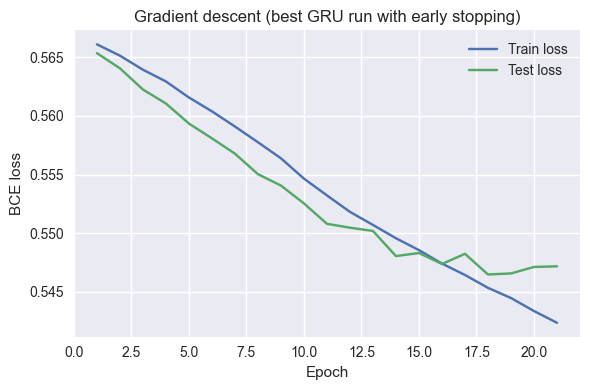


Final AUC (best run) — Train: 0.621 | Test: 0.653


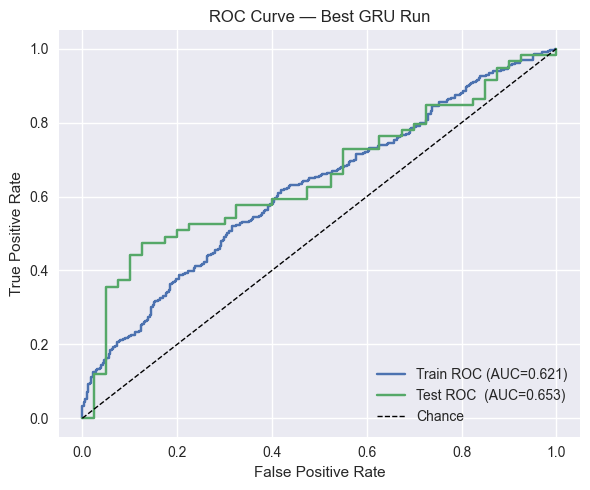

In [18]:
# === Gradient descent with Early Stopping + multi-restarts; saves best p_te/y_te ===
import torch, numpy as np, matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, roc_curve   

assert 'best' in globals(), "Run the grid search cell first to define `best`."
assert 'GRUClassifier' in globals(), "Define GRUClassifier earlier (Cell A)."

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------
# Data loaders (consistent)
# ---------------------------
def _make_loader(X, y, bs=64, shuffle=False):
    class _DS(torch.utils.data.Dataset):
        def __init__(self, X, y): self.X=torch.from_numpy(X); self.y=torch.from_numpy(y)
        def __len__(self): return self.X.shape[0]
        def __getitem__(self,i): return self.X[i], self.y[i]
    return DataLoader(_DS(X, y), batch_size=bs, shuffle=shuffle)

train_loader = _make_loader(X_train, y_train, bs=64, shuffle=True)
test_loader  = _make_loader(X_test,  y_test,  bs=64, shuffle=False)

# ---------------------------
# Training helpers
# ---------------------------
pos_rate   = float(y_train.mean())
pos_weight = (1.0 - pos_rate) / max(pos_rate, 1e-8)
def build_model_and_opt(lr):
    model = GRUClassifier(
        input_size=X_train.shape[2],
        hidden_size=int(best["hidden_size"]),
        num_layers=int(best["num_layers"]),
        dropout=float(best["dropout"]),
    ).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, dtype=torch.float32, device=device))
    optimizer = torch.optim.Adam(model.parameters(), lr=float(lr), weight_decay=1e-5)
    return model, criterion, optimizer

@torch.no_grad()
def _eval_loss(m, loader, criterion):
    m.eval(); tot, n = 0.0, 0
    for Xb, yb in loader:
        Xb = Xb.to(device).float(); yb = yb.to(device).float()
        tot += criterion(m(Xb), yb).item() * Xb.size(0)
        n   += Xb.size(0)
    return tot / max(n, 1)

@torch.no_grad()
def _predict_proba(m, loader):
    m.eval(); P, Y = [], []
    for Xb, yb in loader:
        p = torch.sigmoid(m(Xb.to(device).float())).cpu().numpy()
        P.append(p); Y.append(yb.numpy())
    return np.concatenate(P), np.concatenate(Y)

def seed_everything(seed):
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ---------------------------
# Multi-restart training
# ---------------------------
N_RESTARTS  = 50
MAX_EPOCHS  = 150
PATIENCE    = 3
MIN_DELTA   = 1e-4

run_summaries = []
best_global = {
    "test_auc": -np.inf,
    "state": None,
    "train_losses": None,
    "test_losses": None,
    "seed": None,
}

for r in range(1, N_RESTARTS+1):
    seed = 1000 + r
    seed_everything(seed)

    model, criterion, optimizer = build_model_and_opt(lr=float(best["lr"]))

    best_te_loss = float('inf')
    best_state   = None
    no_improve   = 0
    tr_hist, te_hist = [], []

    for ep in range(1, MAX_EPOCHS+1):
        model.train()
        for Xb, yb in train_loader:
            Xb = Xb.to(device).float(); yb = yb.to(device).float()
            optimizer.zero_grad(set_to_none=True)
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        tr_loss = _eval_loss(model, train_loader, criterion)
        te_loss = _eval_loss(model, test_loader,  criterion)
        tr_hist.append(tr_loss); te_hist.append(te_loss)

        improved = (best_te_loss - te_loss) > MIN_DELTA
        if improved:
            best_te_loss = te_loss
            best_state   = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve   = 0
        else:
            no_improve += 1

        if ep == 1 or ep % 10 == 0:
            print(f"[Run {r}/{N_RESTARTS}] Epoch {ep:03d} | train={tr_loss:.4f} | test={te_loss:.4f} | best_test={best_te_loss:.4f} | patience={no_improve}/{PATIENCE}")

        if no_improve >= PATIENCE:
            print(f"[Run {r}] Early stopping at epoch {ep} (no improvement for {PATIENCE} epochs).")
            break

    # Evaluate with best weights of this run
    if best_state is not None:
        model.load_state_dict(best_state)
    p_tr_run, y_tr_run = _predict_proba(model, train_loader)
    p_te_run, y_te_run = _predict_proba(model, test_loader)
    auc_tr_run = roc_auc_score(y_tr_run, p_tr_run) if len(np.unique(y_tr_run))>1 else np.nan
    auc_te_run = roc_auc_score(y_te_run, p_te_run) if len(np.unique(y_te_run))>1 else np.nan

    run_summaries.append({
        "run": r, "seed": seed,
        "best_test_loss": best_te_loss,
        "train_auc": auc_tr_run, "test_auc": auc_te_run
    })
    print(f"[Run {r}] AUC — Train: {auc_tr_run:.3f} | Test: {auc_te_run:.3f}")

    if (auc_te_run > best_global["test_auc"]) or (
        np.isclose(auc_te_run, best_global["test_auc"]) and best_te_loss < (best_global.get("best_test_loss") or np.inf)
    ):
        best_global.update({
            "test_auc": auc_te_run,
            "state": best_state,
            "train_losses": tr_hist,
            "test_losses": te_hist,
            "seed": seed,
            "best_test_loss": best_te_loss,
            "p_tr": p_tr_run, "y_tr": y_tr_run,
            "p_te": p_te_run, "y_te": y_te_run,
        })

# ---------------------------
# Load the best run and expose predictions for later cells
# ---------------------------
assert best_global["state"] is not None, "No best state captured."
model, criterion, optimizer = build_model_and_opt(lr=float(best["lr"]))
model.load_state_dict(best_global["state"])

p_tr, y_tr = best_global["p_tr"], best_global["y_tr"]
p_te, y_te = best_global["p_te"], best_global["y_te"]

print("\n=== Multi-restart summary ===")
import pandas as _pd
print(_pd.DataFrame(run_summaries).sort_values("test_auc", ascending=False).to_string(index=False))
print(f"\nSelected best run (by Test AUC): seed={best_global['seed']} | "
      f"Test AUC={best_global['test_auc']:.3f} | Best Test Loss={best_global['best_test_loss']:.4f}")

# ---------------------------
# Plot gradient descent curve for the best run
# ---------------------------
plt.figure(figsize=(6,4))
plt.plot(range(1, len(best_global["train_losses"])+1), best_global["train_losses"], label="Train loss")
plt.plot(range(1, len(best_global["test_losses"])+1),  best_global["test_losses"],  label="Test loss")
plt.xlabel("Epoch"); plt.ylabel("BCE loss")
plt.title("Gradient descent (best GRU run with early stopping)")
plt.legend(); plt.tight_layout(); plt.show()

# Final AUCs for the selected best model
final_auc_tr = roc_auc_score(y_tr, p_tr) if len(np.unique(y_tr))>1 else np.nan
final_auc_te = roc_auc_score(y_te, p_te) if len(np.unique(y_te))>1 else np.nan
print(f"\nFinal AUC (best run) — Train: {final_auc_tr:.3f} | Test: {final_auc_te:.3f}")

# ---------------------------
# ROC curves (Train & Test)
# ---------------------------
fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
fpr_te, tpr_te, _ = roc_curve(y_te, p_te)

plt.figure(figsize=(6,5))
plt.plot(fpr_tr, tpr_tr, label=f"Train ROC (AUC={final_auc_tr:.3f})")
plt.plot(fpr_te, tpr_te, label=f"Test ROC  (AUC={final_auc_te:.3f})")
plt.plot([0,1], [0,1], 'k--', lw=1, label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Best GRU Run")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Threshold sweep → pick best threshold & report metrics/plots
- **What it does:** Sweeps probability thresholds (0.05→0.95) and computes **Accuracy, Precision, Recall, F1, ROC-AUC, TNR, Balanced Accuracy, Youden’s J** for each threshold on the **TEST** set.
- **Selection rule:** Chooses the **best threshold** by `CRITERION` (default **`bal`** = max balanced accuracy). Alternatives supported: `f1`, `youden`, `acc`, or `prec_at_70`.
- **Outputs:** Prints the **best-threshold metric row**, then full **Train/Test** metric blocks (including `classification_report`) at that threshold.
- **Visuals:** Plots **confusion matrices** for Train & Test at the chosen threshold, and a **metric vs. threshold** chart to show how F1/Acc/Precision/Recall/BalAcc evolve.
- **Notes:** Uses the **probabilities** `p_tr/p_te` from the selected model (not raw logits) and guards against division-by-zero via `zero_division=0`.


=== Best threshold by bal ===
thr        0.500000
auc        0.652542
acc        0.626263
prec       0.823529
rec        0.474576
f1         0.602151
tnr        0.850000
bal        0.662288
youden     0.324576
tp        28.000000
fp         6.000000
tn        34.000000
fn        31.000000

=== Train Metrics @ thr=0.50 ===
Accuracy:  0.5808
Precision: 0.6868
Recall:    0.5342
F1-Score:  0.6010
ROC-AUC:   0.6210
TNR:       0.6481  | Balanced Acc: 0.5912

--- Classification Report ---
              precision    recall  f1-score   support

           0     0.4907    0.6481    0.5585       324
           1     0.6868    0.5342    0.6010       468

    accuracy                         0.5808       792
   macro avg     0.5887    0.5912    0.5797       792
weighted avg     0.6066    0.5808    0.5836       792


=== Test Metrics @ thr=0.50 ===
Accuracy:  0.6263
Precision: 0.8235
Recall:    0.4746
F1-Score:  0.6022
ROC-AUC:   0.6525
TNR:       0.8500  | Balanced Acc: 0.6623

--- Classification 

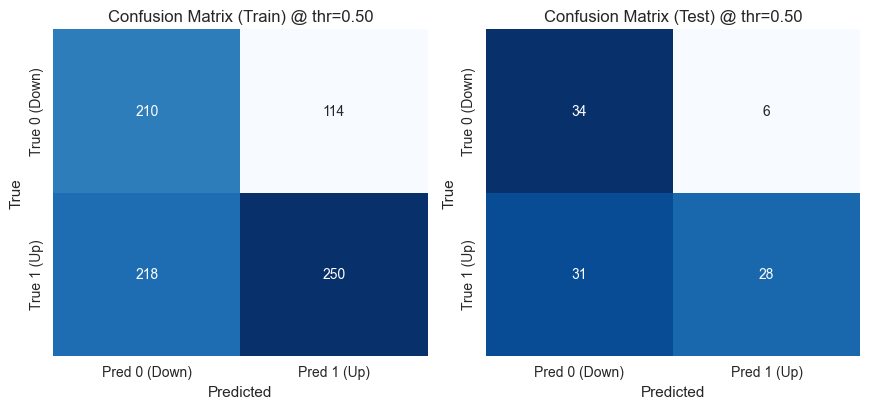

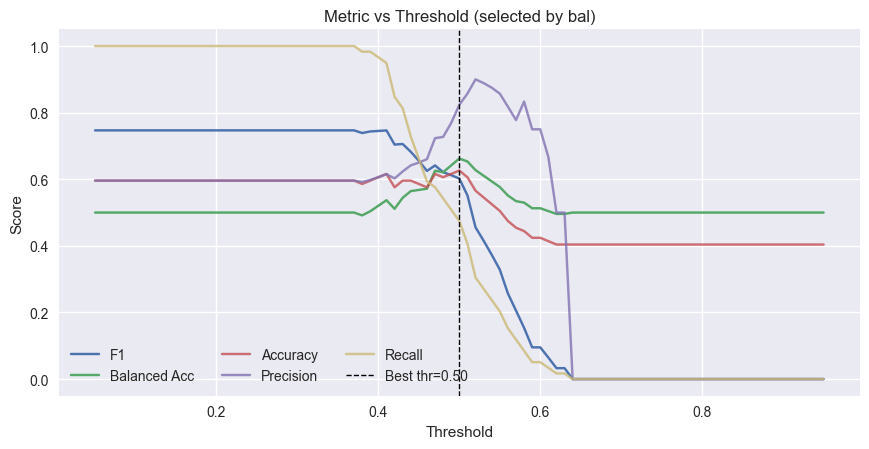

In [19]:
# === Threshold sweep → pick best → report Train & Test metrics/plots ===
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt

# --- Inputs from earlier cells (must exist) ---
assert 'p_tr' in globals() and 'y_tr' in globals(), "Need train probs/labels: p_tr, y_tr."
assert 'p_te' in globals() and 'y_te' in globals(), "Need test probs/labels: p_te, y_te."

# ---------------------------
# Config: how to choose "best" threshold
# ---------------------------
CRITERION = "bal"     # options: "bal", "f1", "youden", "acc", "prec_at_70" (precision≥70%, then max recall)
THR_GRID  = np.round(np.arange(0.05, 0.951, 0.01), 2)

def _metrics(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tnr = tn / (tn + fp) if (tn + fp) else 0.0
    bal = 0.5 * (rec + tnr)
    youden = rec + tnr - 1.0
    return {
        "thr": thr, "auc": auc, "acc": acc, "prec": prec, "rec": rec, "f1": f1,
        "tnr": tnr, "bal": bal, "youden": youden,
        "tp": tp, "fp": fp, "tn": tn, "fn": fn
    }

def sweep_thresholds(y_true, y_prob, thr_grid):
    rows = [_metrics(y_true, y_prob, t) for t in thr_grid]
    return pd.DataFrame(rows)

# --- Sweep on the TEST set (selection should be based on test objective) ---
thr_df = sweep_thresholds(y_te, p_te, THR_GRID)

# --- Choose best per CRITERION ---
if CRITERION == "bal":
    best_row = thr_df.loc[thr_df['bal'].idxmax()]
elif CRITERION == "f1":
    best_row = thr_df.loc[thr_df['f1'].idxmax()]
elif CRITERION == "youden":
    best_row = thr_df.loc[thr_df['youden'].idxmax()]
elif CRITERION == "acc":
    best_row = thr_df.loc[thr_df['acc'].idxmax()]
elif CRITERION == "prec_at_70":
    eligible = thr_df[thr_df['prec'] >= 0.70]
    best_row = eligible.loc[eligible['rec'].idxmax()] if len(eligible) else thr_df.loc[thr_df['f1'].idxmax()]
else:
    raise ValueError(f"Unknown CRITERION '{CRITERION}'")

best_thr = float(best_row['thr'])
print(f"\n=== Best threshold by {CRITERION} ===")
print(best_row[['thr','auc','acc','prec','rec','f1','tnr','bal','youden','tp','fp','tn','fn']].to_string())

# --- Helper to print full block at chosen threshold ---
def report_block(y_true, y_prob, name):
    y_pred = (y_prob >= best_thr).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob) if len(np.unique(y_true))>1 else np.nan
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tnr = tn / (tn + fp) if (tn + fp) else 0.0
    bal = 0.5 * (rec + tnr)
    print(f"\n=== {name} Metrics @ thr={best_thr:.2f} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")
    print(f"TNR:       {tnr:.4f}  | Balanced Acc: {bal:.4f}")
    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, digits=4))
    return y_pred

# --- Print Train/Test summaries at the chosen threshold ---
y_tr_pred = report_block(y_tr, p_tr, "Train")
y_te_pred = report_block(y_te, p_te, "Test")

# --- Confusion matrices side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(8.8, 4.2))
for ax, (y_true, y_pred, title) in zip(
    axes,
    [(y_tr, y_tr_pred, "Train"), (y_te, y_te_pred, "Test")]
):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                    xticklabels=["Pred 0 (Down)", "Pred 1 (Up)"],
                    yticklabels=["True 0 (Down)", "True 1 (Up)"])
    ax.set_title(f"Confusion Matrix ({title}) @ thr={best_thr:.2f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.show()

# --- Optional: visualize how metrics change with threshold ---
plt.figure(figsize=(8.8, 4.6))
plt.plot(thr_df['thr'], thr_df['f1'],   label='F1')
plt.plot(thr_df['thr'], thr_df['bal'],  label='Balanced Acc')
plt.plot(thr_df['thr'], thr_df['acc'],  label='Accuracy', alpha=0.8)
plt.plot(thr_df['thr'], thr_df['prec'], label='Precision', alpha=0.8)
plt.plot(thr_df['thr'], thr_df['rec'],  label='Recall', alpha=0.8)
plt.axvline(best_thr, color='k', ls='--', lw=1, label=f'Best thr={best_thr:.2f}')
plt.xlabel("Threshold"); plt.ylabel("Score")
plt.title(f"Metric vs Threshold (selected by {CRITERION})")
plt.legend(ncol=3); plt.tight_layout(); plt.show()

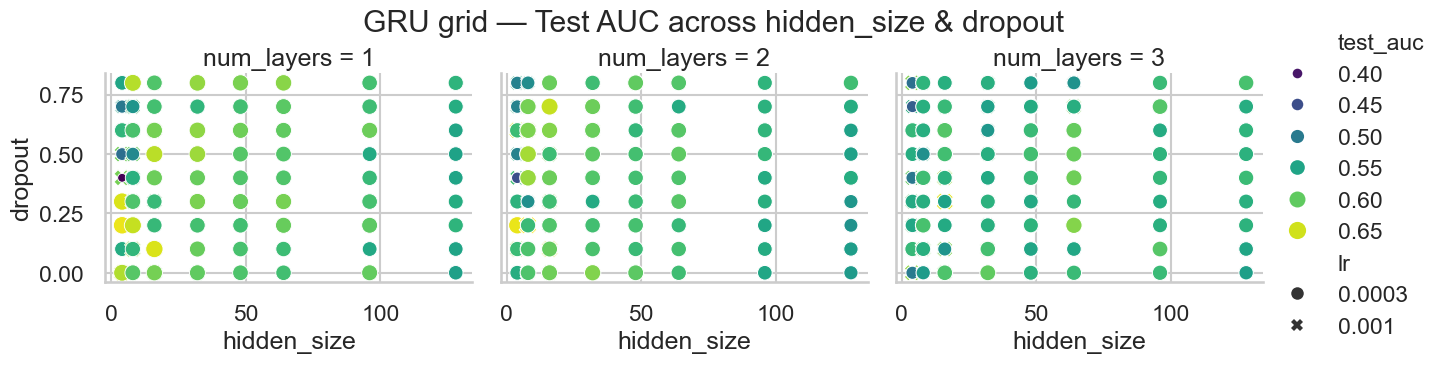

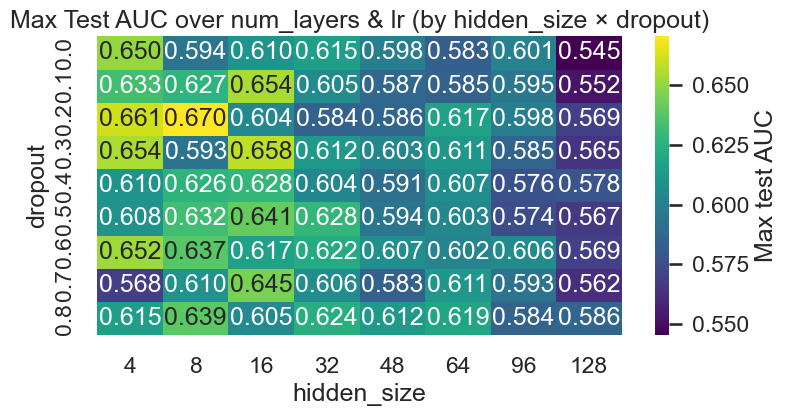


=== Best per num_layers ===
 num_layers  hidden_size  dropout     lr  train_auc  test_auc
          2            8      0.2 0.0010   0.694385  0.670339
          1            4      0.2 0.0003   0.593318  0.661441
          3           16      0.3 0.0010   0.691464  0.658051

=== Best per lr ===
    lr  hidden_size  dropout  num_layers  train_auc  test_auc
0.0010            8      0.2           2   0.694385  0.670339
0.0003            4      0.2           1   0.593318  0.661441


In [20]:
# === Visualize GRU grid search results ===
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_context("talk"); sns.set_style("whitegrid")

assert 'results_df' in globals(), "Run the grid search cell first."

# 1) Scatter: hidden_size vs dropout, colored by test AUC, styled by lr; facet by num_layers
g = sns.relplot(
    data=results_df,
    x="hidden_size", y="dropout",
    hue="test_auc", size="test_auc",
    style="lr", palette="viridis",
    col="num_layers", col_wrap=3,
    kind="scatter", height=3.6, aspect=1.2
)
g.set_titles("num_layers = {col_name}")
g.fig.suptitle("GRU grid — Test AUC across hidden_size & dropout", y=1.03)
plt.show()

# 2) Heatmap (collapsed over num_layers & lr by taking MAX test AUC for each (hidden_size, dropout))
collapsed = (results_df
             .groupby(['hidden_size','dropout'], as_index=False)['test_auc']
             .max()
             .pivot(index='dropout', columns='hidden_size', values='test_auc')
            )

plt.figure(figsize=(8,4.5))
sns.heatmap(collapsed, annot=True, fmt=".3f", cmap="viridis", cbar_kws={'label':'Max test AUC'})
plt.title("Max Test AUC over num_layers & lr (by hidden_size × dropout)")
plt.ylabel("dropout"); plt.xlabel("hidden_size")
plt.tight_layout(); plt.show()

# 3) Quick tables: best per num_layers and per lr
best_per_layers = (results_df.sort_values("test_auc", ascending=False)
                   .groupby('num_layers', as_index=False).first()
                   .sort_values('test_auc', ascending=False))
best_per_lr = (results_df.sort_values("test_auc", ascending=False)
               .groupby('lr', as_index=False).first()
               .sort_values('test_auc', ascending=False))

print("\n=== Best per num_layers ===")
print(best_per_layers[['num_layers','hidden_size','dropout','lr','train_auc','test_auc']].to_string(index=False))

print("\n=== Best per lr ===")
print(best_per_lr[['lr','hidden_size','dropout','num_layers','train_auc','test_auc']].to_string(index=False))

## QuantStats prep — daily strategy from next-month signals
- **Goal:** Turn TEST-set probabilities (`p_te`) into a **long-only daily return series** and compare it to an **equal-weight sector benchmark**, then generate a QuantStats tear sheet.

**Inputs & assumptions**
- Uses `df` with columns **`Ticker, Date, Close, Sector`** (and computes `Return_verified` if missing).
- Uses `meta_test` (must include **`Sector`** and **`Month`**) aligned to `p_te`.
- Threshold **`thr = 0.50`** → `Signal = 1` means **go long next month**; signals are **shifted to `t+1`** via `TradeMonth = Month + 1` to avoid look-ahead.

**Pipeline**
1. **Daily sector returns:** For each `Date × Sector`, compute the equal-weight mean of stock **simple returns** (`SecRet`).
2. **Attach signals:** Merge **shifted monthly** signals onto each sector-day within that trading month.
3. **Strategy returns:** Per day, take the **average of `SecRet` across signaled sectors**; if no sectors signaled, return **0 (cash)**.
4. **Benchmark:** Per day, take the **average of `SecRet` across all sectors** (always fully invested).
5. **Indexing:** Ensure both `strat_ret` and `bench_ret` use a **DatetimeIndex**.

**Outputs**
- Prints shapes and a small sample of the two daily series.
- **QuantStats**: 
  - Saves a full HTML tear sheet to `tearsheet_sector_strategy.html`.
  - Displays an inline **full report** (cum. returns, drawdowns, Sharpe, etc.).


In [21]:
# === QuantStats prep: daily strategy returns from NEXT-MONTH signals (monthly rebalancing) ===
import numpy as np
import pandas as pd

# --- 0) Ensure daily simple returns per ticker are present ---
if 'Return_verified' not in df.columns:
    df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)
    df['Return_verified'] = df.groupby('Ticker')['Close'].pct_change()
    # first day per ticker -> NaN
    first_idx = df.groupby('Ticker', group_keys=False)['Date'].head(1).index
    df.loc[first_idx, 'Return_verified'] = np.nan

# --- 1) Build long-only monthly signals from TEST predictions (shift to next month) ---
# p_te : predicted probabilities for meta_test rows
# meta_test : contains ['Sector','Month','Month_ts', ...] for the TEST window
thr = 0.50
signals_df = meta_test.copy()

# Ensure Month is a monthly Period (robust to either Period or Timestamp)
if not pd.api.types.is_period_dtype(signals_df['Month']):
    signals_df['Month'] = signals_df['Month'].astype('period[M]')

signals_df['Signal'] = (p_te >= thr).astype(int)  # 1 = long next month, 0 = skip

# We trade in month t+1 using features from month t
signals_df['TradeMonth'] = signals_df['Month'] + 1

# --- 2) Define the DAILY test window from first to last trading month ---
test_start = signals_df['TradeMonth'].min().to_timestamp(how='start')
test_end   = signals_df['TradeMonth'].max().to_timestamp(how='end')

# --- 3) Sector daily equal-weight returns across constituents ---
daily = df.loc[(df['Date'] >= test_start) & (df['Date'] <= test_end)].copy()
daily = daily.dropna(subset=['Return_verified'])

sec_daily = (daily.groupby(['Date', 'Sector'])['Return_verified']
                  .mean()
                  .reset_index(name='SecRet'))
sec_daily['Month'] = sec_daily['Date'].dt.to_period('M')

# --- 4) Attach the *shifted* (t+1) monthly signal to each sector-day within that trading month ---
signals_for_merge = signals_df[['Sector', 'TradeMonth', 'Signal']].rename(
    columns={'TradeMonth': 'Month'}
)
sec_daily = sec_daily.merge(signals_for_merge, on=['Sector', 'Month'], how='left')
sec_daily['Signal'] = sec_daily['Signal'].fillna(0).astype(int)

# --- 5) Build the daily strategy (equal-weight across selected sectors); monthly rebalancing is implicit ---
def _avg_selected(d):
    n = d['Signal'].sum()
    if n <= 0:
        return 0.0  # stay in cash if no sectors selected
    return d.loc[d['Signal'] == 1, 'SecRet'].mean()

strat_ret = sec_daily.groupby('Date').apply(_avg_selected).rename('strategy').sort_index()

# --- 6) Benchmark: equal-weight across *all* sectors each day ---
bench_ret = (sec_daily.groupby('Date')['SecRet']
                    .mean()
                    .rename('benchmark')
                    .sort_index())

print("Daily series shapes:", strat_ret.shape, bench_ret.shape)
print("Sample:\n", pd.concat([strat_ret.head(3), bench_ret.head(3)], axis=1))

Daily series shapes: (167,) (167,)
Sample:
                      strategy  benchmark
Date                                    
2025-02-03 05:00:00  0.001044  -0.002808
2025-02-04 05:00:00  0.002126   0.006770
2025-02-05 05:00:00  0.010087   0.008031


/var/folders/5_/c20qy50s35jdz3bv32kv3lpw0000gn/T/ipykernel_94050/2069912727.py:20: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  if not pd.api.types.is_period_dtype(signals_df['Month']):
/var/folders/5_/c20qy50s35jdz3bv32kv3lpw0000gn/T/ipykernel_94050/2069912727.py:55: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  strat_ret = sec_daily.groupby('Date').apply(_avg_selected).rename('strategy').sort_index()


                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               2025-02-03   2025-02-03
End Period                 2025-10-01   2025-10-01
Risk-Free Rate             0.0%         0.0%
Time in Market             100.0%       100.0%

Cumulative Return          16.19%       23.84%
CAGR﹪                     25.42%       38.07%

Sharpe                     1.39         1.64
Prob. Sharpe Ratio         87.09%       91.33%
Smart Sharpe               1.32         1.55
Sortino                    2.07         2.51
Smart Sortino              1.96         2.38
Sortino/√2                 1.47         1.77
Smart Sortino/√2           1.39         1.68
Omega                      1.45         1.45

Max Drawdown               -13.89%      -13.11%
Max DD Date                2025-04-08   2025-04-08
Max DD Period Start        2025-02-19   2025-04-03
Max DD Period End          2025-05-12   2025-04-28
Longest DD Days            82           33
Vola

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2025-04-03,2025-04-08,2025-04-28,26,-13.113404,-12.116749
2,2025-02-21,2025-03-04,2025-03-14,21,-3.630936,-3.592629
3,2025-08-21,2025-09-08,2025-09-22,33,-2.663031,-2.612258
4,2025-05-20,2025-05-23,2025-06-05,17,-2.270938,-2.171106
5,2025-07-30,2025-07-31,2025-08-07,9,-2.077577,-1.462488


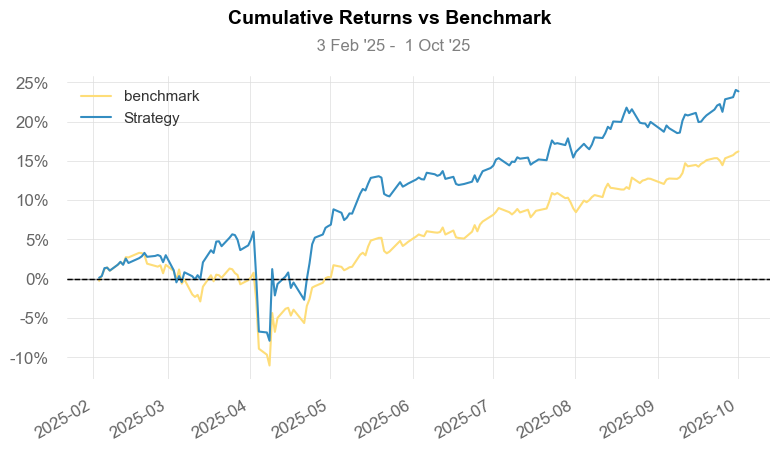

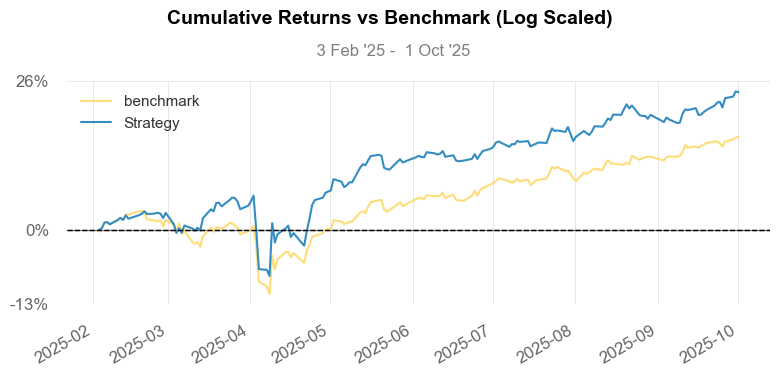

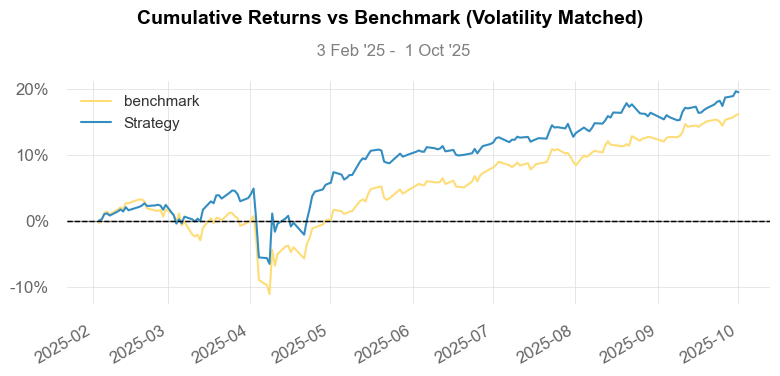

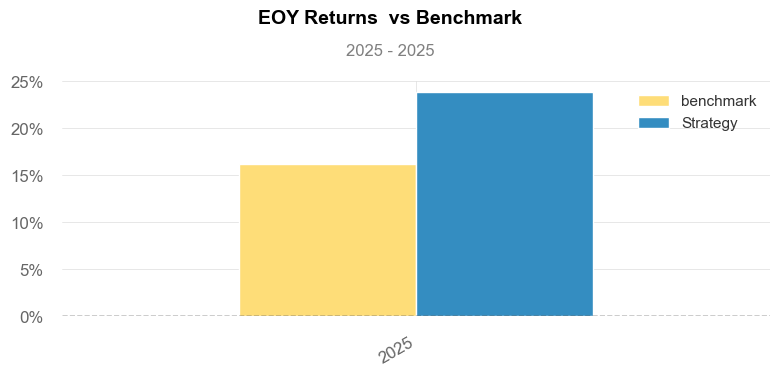

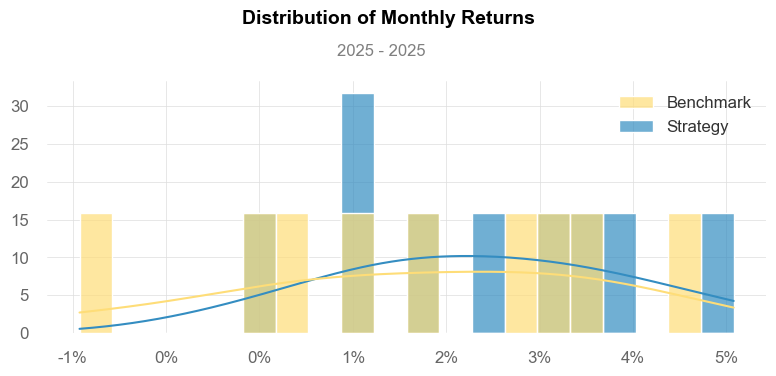

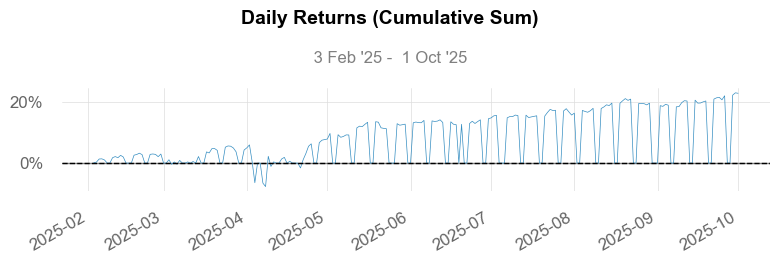

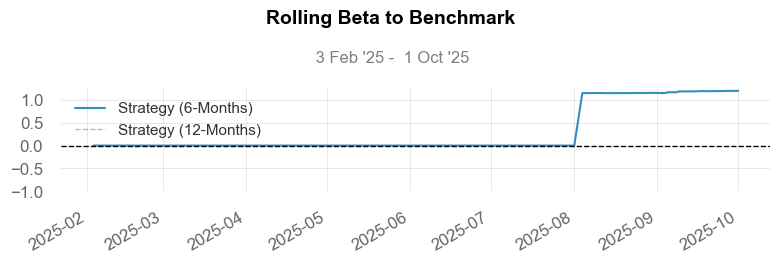

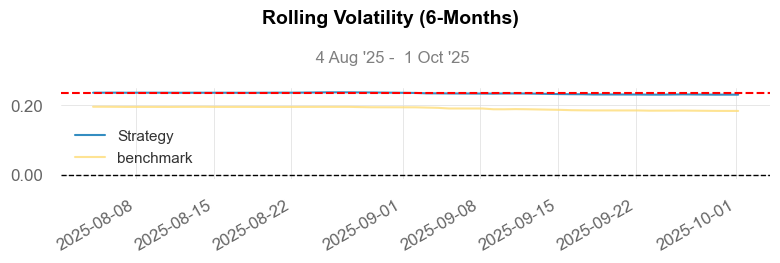

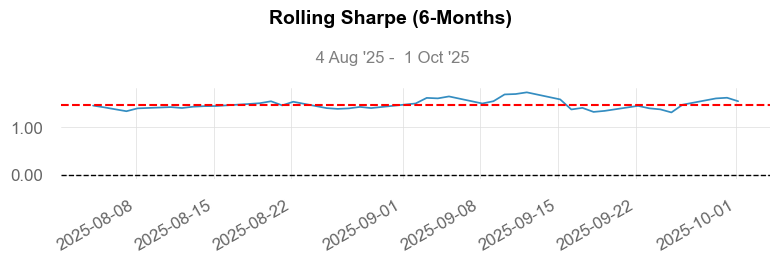

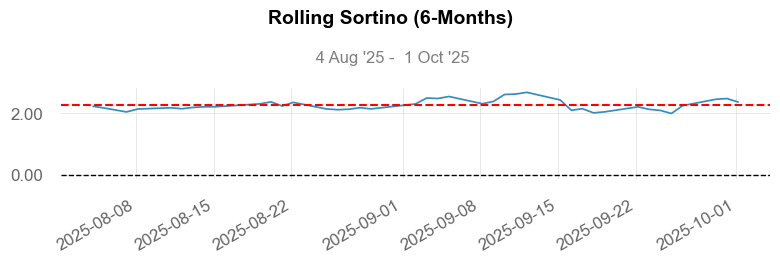

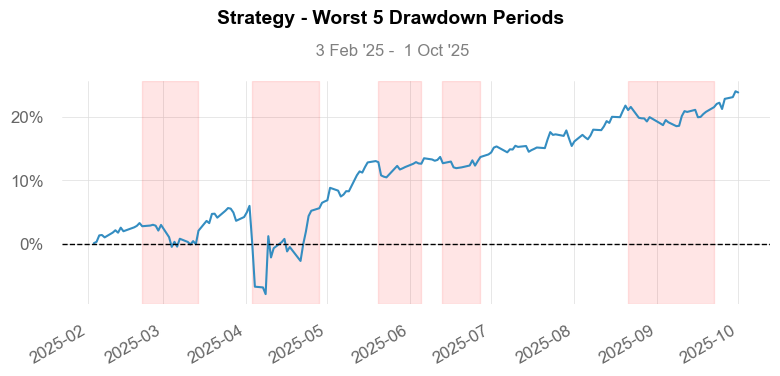

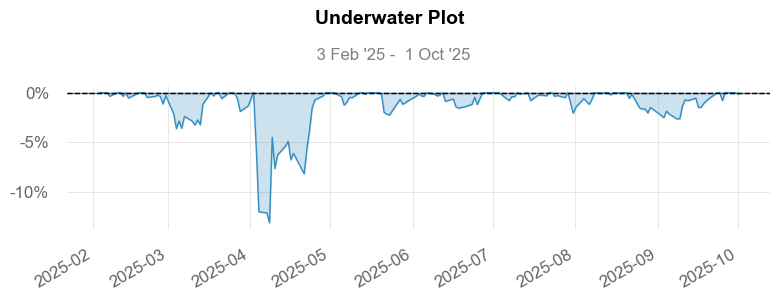

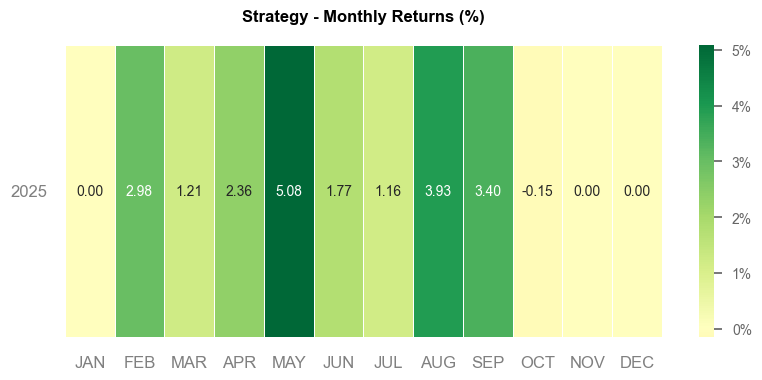

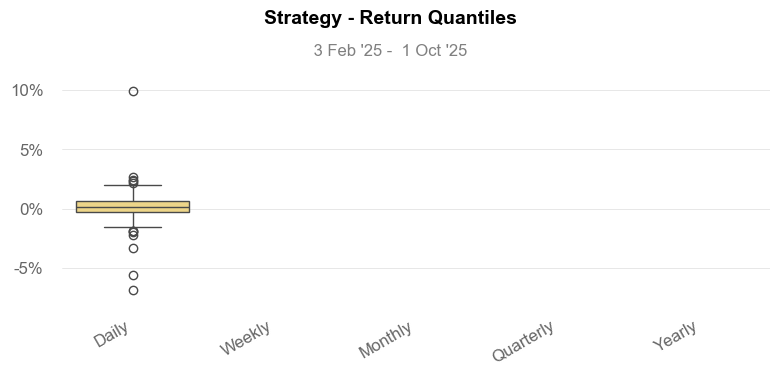

✓ QuantStats tear sheet generated. For the full HTML, open: tearsheet_sector_strategy.html


In [22]:
# === QuantStats tear sheet ===
# pip install if needed (uncomment next line if quantstats isn't installed)
# !pip install --quiet quantstats

import quantstats as qs

# ensure datetime index
strat_ret.index = pd.DatetimeIndex(strat_ret.index)
bench_ret.index = pd.DatetimeIndex(bench_ret.index)

# Option A: full HTML report file (saves to working directory)
qs.reports.html(
    strat_ret,
    benchmark=bench_ret,
    title="Sector Next-Month Strategy (Model = Best GRU/LSTM, Long-Only)",
    output="tearsheet_sector_strategy.html",
    figfmt="png"
)

# Option B: show key plots & stats inline (not saved)
qs.reports.full(
    strat_ret,
    benchmark=bench_ret,
    title="Sector Next-Month Strategy (Model = Best GRU/LSTM, Long-Only)",
    display=True,  # show in notebook
    output=None
)

print("✓ QuantStats tear sheet generated. For the full HTML, open: tearsheet_sector_strategy.html")